In [5]:
%%capture captured_output
%%time
%pip install numpy==1.26 matplotlib==3.9.2 tensorflow==2.19
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
--index-url https://download.pytorch.org/whl/cpu

In [6]:
output_text = captured_output.stdout
lines = output_text.splitlines()
output_last_10_lines = '\n'.join(lines[-10:])
if "error" in output_last_10_lines.lower():
    print("Library installation failed!")
    print("--- Error Details ---")
    print(output_last_10_lines)
else:
    print("Library installation was successful, let's proceed ahead")

Library installation was successful, let's proceed ahead


In [7]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import skillsnetwork

In [8]:
#url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"

#extraction_path = "."
#await skillsnetwork.prepare(url = url, path = extraction_path, overwrite = True)

In [9]:
# Define directories
base_dir = './images_dataSAT/'
# Note: It's common practice for class directories to have clear names.
# Using 'class_0' and 'class_1' is good for automatic inference.
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

In [10]:
## You can use this cell to type the code to answer the question.

# Initialize empty lists to store paths and labels
all_image_paths = []
all_labels = []

# Define the labels for each class
label_non_agri = 0
label_agri = 1

# Populate the lists
for fname in os.listdir(dir_non_agri):
    all_image_paths.append(os.path.join(dir_non_agri, fname))
    all_labels.append(label_non_agri)

for fname in os.listdir(dir_agri):
    all_image_paths.append(os.path.join(dir_agri, fname))
    all_labels.append(label_agri)

print(f"Total images: {len(all_image_paths)}")
print(f"Total labels: {len(all_labels)}")

Total images: 6000
Total labels: 6000


In [11]:
## You can use this cell to type the code to answer the question.

# Use zip to bind paths and labels, then shuffle
temp = list(zip(all_image_paths, all_labels))
np.random.shuffle(temp)
all_image_paths, all_labels = zip(*temp)

print("First 5 paths and labels (after shuffling):")
print(list(zip(all_image_paths[:5], all_labels[:5])))

First 5 paths and labels (after shuffling):
[('./images_dataSAT/class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_13696.jpg', 1), ('./images_dataSAT/class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_18286.jpg', 1), ('./images_dataSAT/class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_6997.jpg', 0), ('./images_dataSAT/class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_3612.jpg', 0), ('./images_dataSAT/class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_10391.jpg', 1)]


In [12]:
def custom_data_generator(image_paths, labels, batch_size, target_size=(64, 64)):
    """A custom data generator to feed a Keras model."""
    num_samples = len(image_paths)
    while True: 
        # Shuffle data at the beginning of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        shuffled_paths = np.array(image_paths)[indices]
        shuffled_labels = np.array(labels)[indices]
        
        # Generate batch data
        for offset in range(0, num_samples, batch_size):
            batch_paths = shuffled_paths[offset:offset+batch_size]
            batch_labels = shuffled_labels[offset:offset+batch_size]
            
            # Load and preprocess images from the batch
            batch_images = []
            for path in batch_paths:
                img = tf.keras.utils.load_img(path, target_size=target_size)
                img_array = tf.keras.utils.img_to_array(img)
                batch_images.append(img_array)
            
            # Normalize and yield the batch data
            yield np.array(batch_images) / 255.0, np.array(batch_labels)

Images batch shape: (8, 64, 64, 3)
Labels batch shape: (8,)


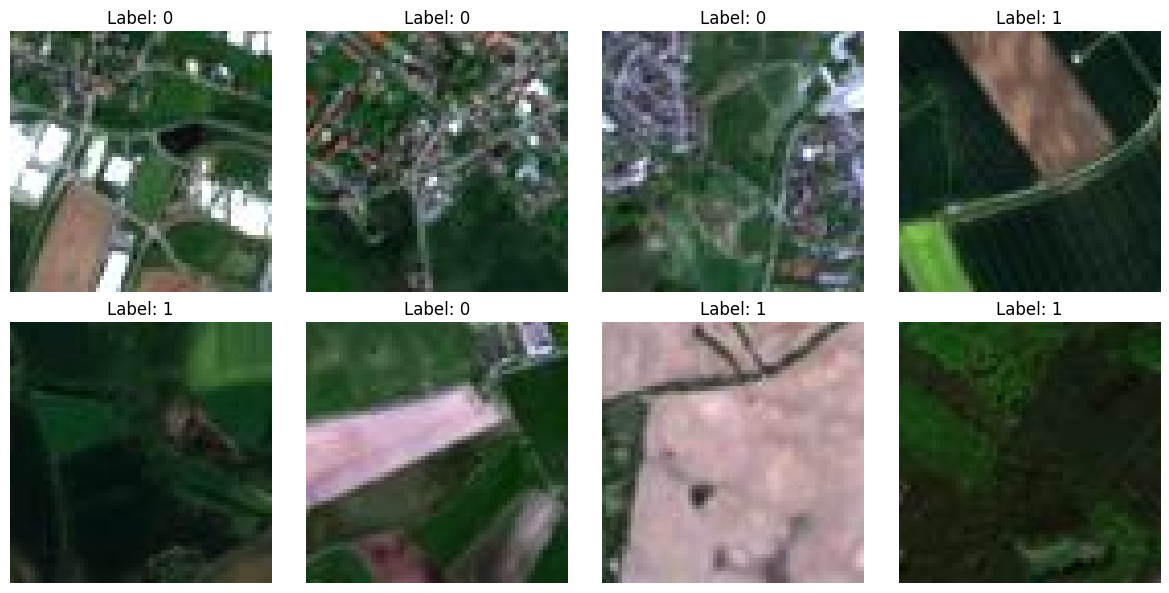

In [13]:
## You can use this cell to type the code to answer the question.

batch_size = 8
data_generator = custom_data_generator(
    image_paths=all_image_paths,
    labels=all_labels,
    batch_size=batch_size
)

# Get one batch of data
images, labels = next(data_generator)

# Print batch shape
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")

# Display images and labels
plt.figure(figsize=(12, 6))
for i in range(batch_size):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

# Create a training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',          # Labels are generated from directory structure
    label_mode='int',           # Labels are encoded as integers (0, 1, ...)
    validation_split=0.2,       # Reserve 20% of images for validation
    subset='training',          # This is the training set
    seed=1337,                  # Shuffle seed for reproducible splits
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


In [15]:
## You can use this cell to type the code to answer the question

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

print(f"Validation dataset class names: {val_ds.class_names}")

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.
Validation dataset class names: ['class_0_non_agri', 'class_1_agri']


Class names inferred by Keras: ['class_0_non_agri', 'class_1_agri']


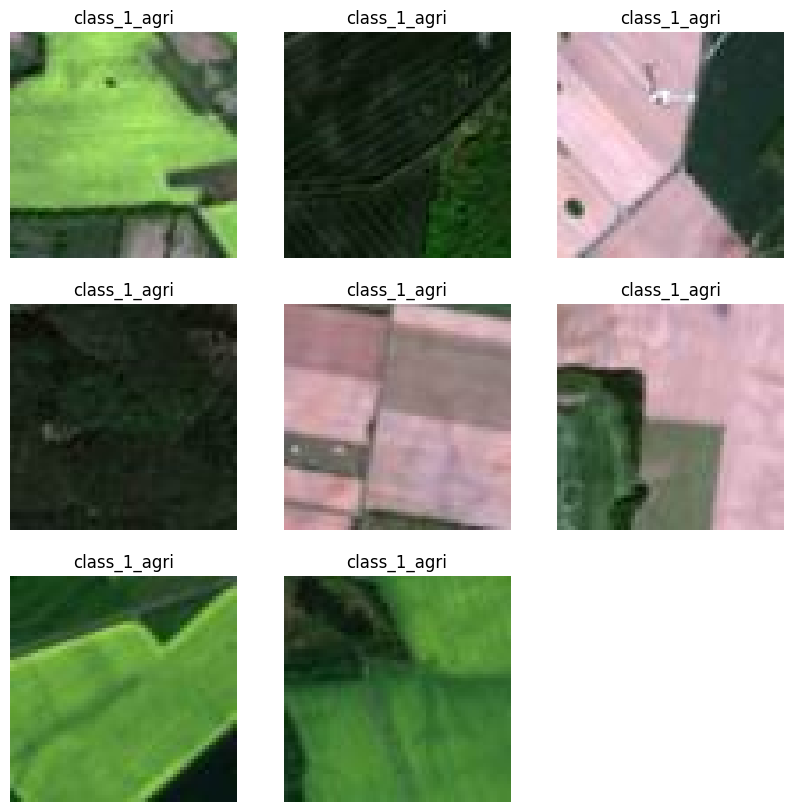

In [16]:
print(f"Class names inferred by Keras: {train_ds.class_names}")

# Let's visualize one batch from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(BATCH_SIZE):
        ax = plt.subplot(3, 3, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# Apply augmentation to the training dataset using map
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset is now configured for high performance!")

Dataset is now configured for high performance!
